In [1]:
!python -V

Python 3.11.15


## 1. Import

In [1]:
import pandas as pd
import numpy as np
import ast
import pickle

from sklearn.cluster import DBSCAN

## 2. Data loading

In [5]:
df = pd.read_excel("hotels_Turkey__v08062026.xlsx")
df.head(5)

,id,name,address,gmap_latitude,gmap_longitude,phone,site,check_in,check_out,in_hotel,...,sletat_json__groups.health_and_beauty,sletat_json__groups.pool,sletat_json__groups.beach_line,sletat_json__groups.sports,sletat_json__groups.business_services,sletat_json__groups.children_services,sletat_json__groups.beach,sletat_json__groups.beach_type,sletat_json__groups.hotel_type,sletat_json__groups.internet
0,23209,Gleam Collection,NaN,41.04999,28.98789,+90 (212) 368-71-75,https://www.gleamcollection.com/index.php,NaN,NaN,NaN,...,"['массаж', 'сауна', 'спа и оздоровительный цен...",NaN,NaN,['фитнес-центр'],NaN,['детская кроватка в номере'],NaN,NaN,['одно здание'],['wi-fi в номере']
1,23213,Eras Alanya,NaN,36.47548,32.11142,NaN,https://erasotel.com/,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,23214,Club Dizalya,NaN,36.57907,31.88865,+90 (242) 512-05-50,https://dizalyahotels.com/tr/Club-Dizalya,NaN,NaN,NaN,...,"['массаж', 'сауна', 'спа и оздоровительный цен...",['открытый бассейн'],['один-ая пляжная линия'],"['фитнес-центр', 'настольный теннис', 'волейбо...",NaN,"['детская площадка', 'детский клуб', 'детский ...",['частный пляж'],"['песок крупный', 'галька']",['отельный комплекс/большая территория'],"['wi-fi', 'wi-fi в номере']"
3,23215,Hatipoglu Beach,NaN,36.54698,31.98431,+90 (242) 519-21-00,https://www.hatipoglubeach.com/?Iletisim,NaN,NaN,NaN,...,NaN,['открытый бассейн'],['два-ая пляжная линия'],"['водные виды', 'волейбол']",NaN,['детский бассейн'],['муниципальный пляж'],['песок жёлтый'],['одно здание'],['wi-fi']
4,23216,Seven Seas Palmeras Bay,NaN,36.57302,31.90147,NaN,https://sevenseaspalmerasbay.com/,NaN,NaN,NaN,...,"['массаж', 'сауна', 'спа и оздоровительный цен...",['открытый бассейн'],['один-ая пляжная линия'],"['фитнес-центр', 'волейбол']","['факс', 'конференц-зал', 'ксерокс']","['детская площадка', 'детский бассейн']",['частный пляж'],['песок жёлтый'],['отельный комплекс/большая территория'],"['wi-fi', 'wi-fi в номере']"


## 3. Data analysis

### 3.1 Commom exploration

In [6]:
df.shape

(2470, 43)

In [7]:
df.duplicated().sum()

0

In [8]:
info_table = pd.DataFrame({
    'dtype': df.dtypes,
    'missing_count': df.isna().sum(),
    'missing_percent': df.isna().mean() * 100,
    'unique_count': df.nunique()
})

info_table.sort_values('missing_percent', ascending=False)

,dtype,missing_count,missing_percent,unique_count
descroom,object,2215,89.676113,254
meal,object,2178,88.178138,180
deschealth_aec,object,2162,87.530364,247
beach,object,2149,87.004049,302
children,object,2109,85.384615,348
in_hotel,object,2092,84.696356,366
therapy,object,2088,84.534413,361
sport,object,2073,83.927126,391
check_out,object,2067,83.684211,14
check_in,object,2066,83.643725,14


### 3.2 Data cleaning

In [10]:
drop_cols = [
    'country_name',
    'site',
    'phone',
    'sletat_json__email',
    'address',
    'check_in',
    'check_out',
    'union_content',
    'feed',
    'meal',
    'sport',
    'beach',
    'children',
    'descroom',
    'in_room',
    'in_hotel',
    'therapy',
    'sletat_text'
]

df_clean = df.drop(columns=drop_cols).copy()

### 3.3 Feature engineering

In [12]:
rename_cols = {
    'sletat_json__rooms': 'rooms_count',
    'sletat_json__groups.common_services': 'common_services',
    'sletat_json__groups.parking': 'parking',
    'sletat_json__groups.room_amenities': 'room_amenities',
    'sletat_json__groups.special_rooms': 'special_rooms',
    'sletat_json__groups.food': 'food_services',
    'sletat_json__groups.transport': 'transport',
    'sletat_json__groups.laundry_services': 'laundry_services',
    'sletat_json__groups.entertainment': 'entertainment',
    'sletat_json__groups.health_and_beauty': 'health_and_beauty',
    'sletat_json__groups.pool': 'pool',
    'sletat_json__groups.beach_line': 'beach_line',
    'sletat_json__groups.sports': 'sports',
    'sletat_json__groups.business_services': 'business_services',
    'sletat_json__groups.children_services': 'children_services',
    'sletat_json__groups.beach': 'beach_services',
    'sletat_json__groups.beach_type': 'beach_type',
    'sletat_json__groups.hotel_type': 'hotel_type',
    'sletat_json__groups.internet': 'internet'
}

df_clean = df_clean.rename(columns=rename_cols)

#### 3.3.1 Accommodation with pets

In [13]:
text = df_clean['deschealth_aec'].fillna('').str.lower()

has_animals = text.str.contains('животн|питомц', regex=True)

df_clean['pets_policy'] = 'unknown'

negative_pattern = r'не\s+\w{0,20}\s*(?:допуска|разреш|предусмотр|принима)|запрещ'
paid_pattern = r'дополнительную плату|доп\. плату|за доплату|за плату|платно'
allowed_pattern = r'допуска|разреш|возможность размещения|возможно размещение|размещение.*возможно'
request_pattern = r'уточнять|по запросу'

df_clean.loc[
    has_animals & text.str.contains(request_pattern, regex=True),
    'pets_policy'
] = 'pets_request'

df_clean.loc[
    has_animals & text.str.contains(allowed_pattern, regex=True),
    'pets_policy'
] = 'pets_allowed'

df_clean.loc[
    has_animals & text.str.contains(paid_pattern, regex=True),
    'pets_policy'
] = 'pets_paid'

df_clean.loc[
    has_animals & text.str.contains(negative_pattern, regex=True),
    'pets_policy'
] = 'no_pets'

<Axes: ylabel='count'>

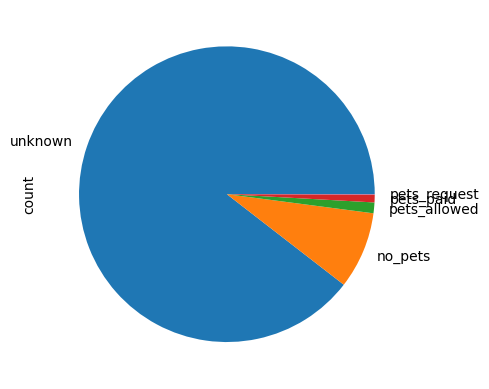

In [14]:
df_clean['pets_policy'].value_counts().plot(kind='pie')

In [15]:
df_clean['has_pets_info'] = (df_clean['pets_policy'] != 'unknown').astype(int)
df_clean = df_clean.drop(columns='deschealth_aec')

#### 3.3.2 Category clarification

In [16]:
df_clean['category_name'].value_counts()

category_name
5*                  899
4*                  790
3*                  490
Special Category    126
Bоutique             79
2*                   20
S Class              13
4*+                  12
Apart                 7
Apart Hotel           7
HV1                   6
Boutique              6
Без звездности        5
3*+                   5
2*+                   2
3* Boutique           1
Self Catering         1
HV2                   1
Name: count, dtype: int64

In [17]:
cat = df_clean['category_name'].fillna('').str.strip().str.lower()

# The data contains the value "Bоutique," where the letter "o" is Cyrillic.
# We'll convert it to the normal spelling "boutique."

cat = cat.str.replace('bоutique', 'boutique', regex=False)

df_clean['hotel_stars'] = pd.NA

df_clean.loc[cat.str.contains('5\\*', regex=True), 'hotel_stars'] = 5
df_clean.loc[cat.str.contains('4\\*', regex=True), 'hotel_stars'] = 4
df_clean.loc[cat.str.contains('3\\*', regex=True), 'hotel_stars'] = 3
df_clean.loc[cat.str.contains('2\\*', regex=True), 'hotel_stars'] = 2

df_clean['hotel_stars'] = df_clean['hotel_stars'].astype('Int64')

In [18]:
df_clean['category_clean'] = 'other'

df_clean.loc[
    cat.str.contains('5\\*|4\\*|3\\*|2\\*', regex=True),
    'category_clean'
] = 'star_hotel'

df_clean.loc[
    cat.str.contains('boutique', regex=True),
    'category_clean'
] = 'boutique'

df_clean.loc[
    cat.str.contains('apart', regex=True),
    'category_clean'
] = 'apart_hotel'

df_clean.loc[
    cat.str.contains('hv1|hv2', regex=True),
    'category_clean'
] = 'holiday_village'

df_clean.loc[
    cat.str.contains('special category', regex=True),
    'category_clean'
] = 'special'

df_clean.loc[
    cat.str.contains('s class', regex=True),
    'category_clean'
] = 's_class'

df_clean.loc[
    cat.str.contains('self catering', regex=True),
    'category_clean'
] = 'self_catering'

df_clean.loc[
    cat.str.contains('без звездности', regex=True),
    'category_clean'
] = 'no_stars'

<Axes: ylabel='count'>

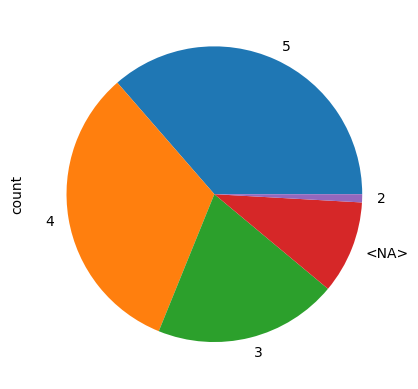

In [19]:
df_clean['hotel_stars'].value_counts(dropna=False).plot(kind='pie')

In [20]:
df_clean['category_clean'].value_counts()

category_clean
star_hotel         2218
special             126
boutique             86
apart_hotel          14
s_class              13
holiday_village       7
no_stars              5
self_catering         1
Name: count, dtype: int64

### 3.4 Expanded exploration

#### 3.4.1 Final features

In [21]:
pd.DataFrame(df_clean.columns)

,0
0,id
1,name
2,gmap_latitude
3,gmap_longitude
4,category_name
5,rooms_count
6,common_services
7,parking
8,room_amenities
9,special_rooms


#### 3.4.2 Gaps

In [22]:
df_clean.isna().sum()

id                      0
name                    0
gmap_latitude           0
gmap_longitude          0
category_name           0
rooms_count           140
common_services       547
parking              1206
room_amenities        330
special_rooms         863
food_services         360
transport            1306
laundry_services     1253
entertainment         844
health_and_beauty     854
pool                  836
beach_line           1070
sports                983
business_services    1220
children_services     959
beach_services       1086
beach_type           1100
hotel_type            488
internet              392
pets_policy             0
has_pets_info           0
hotel_stars           251
category_clean          0
dtype: int64

In [23]:
df_model = df_clean.copy()

##### 3.4.2.1 Rooms count

In [24]:
# We save the original value so as not to lose information
df_model['rooms_count_original'] = df_model['rooms_count']

# 0 and NaN are considered to be the absence of information
df_model['rooms_count_missing'] = (
    df_model['rooms_count'].isna() | (df_model['rooms_count'] == 0)
).astype(int)

# Replace 0 with NaN before calculating the median
df_model['rooms_count'] = df_model['rooms_count'].replace(0, pd.NA)

# Fill in the blanks with the median of the known values
rooms_median = round(df_model['rooms_count'].median())
df_model['rooms_count'] = df_model['rooms_count'].fillna(rooms_median).astype('Int16')

##### 3.4.2.2 Stars

In [25]:
df_model['hotel_stars_for_model'] = df_model['hotel_stars'].astype('string')
df_model['hotel_stars_for_model'] = df_model['hotel_stars_for_model'].fillna('unknown')

##### 3.4.2.3 Services

In [26]:
# List of columns with service groups
service_cols = [
    'common_services',
    'parking',
    'room_amenities',
    'special_rooms',
    'food_services',
    'transport',
    'laundry_services',
    'entertainment',
    'health_and_beauty',
    'pool',
    'beach_line',
    'sports',
    'business_services',
    'children_services',
    'beach_services',
    'beach_type',
    'hotel_type',
    'internet'
]

In [27]:
def to_list(x):
    if pd.isna(x):
        return []
    
    if isinstance(x, list):
        return x
    
    try:
        value = ast.literal_eval(x)
        if isinstance(value, list):
            return value
        else:
            return [value]
    except:
        return [x]

In [28]:
def clean_service_list(values):
    clean_values = []
    
    for value in values:
        value = str(value).strip().lower()
        
        if value != '':
            clean_values.append(value)
    
    return sorted(list(set(clean_values)))

In [29]:
for col in service_cols:
    df_model[col + '_has_info'] = df_model[col].notna().astype(int)
    df_model[col] = df_model[col].apply(to_list)
    df_model[col] = df_model[col].apply(clean_service_list)
    df_model[col + '_count'] = df_model[col].apply(len)

In [30]:
df_model[['id', 'sports', 'sports_has_info']].head(5)

,id,sports,sports_has_info
0,23209,[фитнес-центр],1
1,23213,[],0
2,23214,"[баскетбол, волейбол, групповые занятия, насто...",1
3,23215,"[водные виды, волейбол]",1
4,23216,"[волейбол, фитнес-центр]",1


##### 3.4.2.4 Results

In [31]:
df_model.isna().sum()

id                     0
name                   0
gmap_latitude          0
gmap_longitude         0
category_name          0
                      ..
beach_type_count       0
hotel_type_has_info    0
hotel_type_count       0
internet_has_info      0
internet_count         0
Length: 67, dtype: int64

#### 3.4.3 Distribution

##### 3.4.3.1 Rooms count

<Axes: >

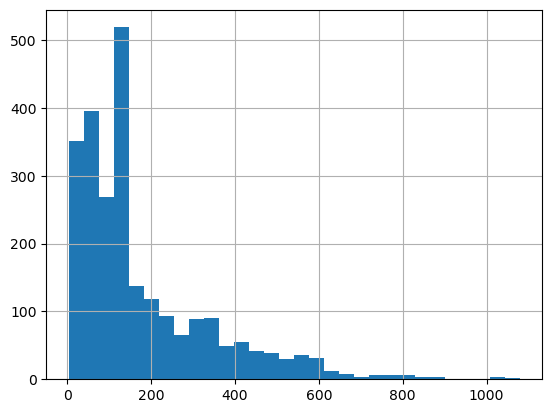

In [32]:
df_model['rooms_count'].hist(bins=30)

<Axes: >

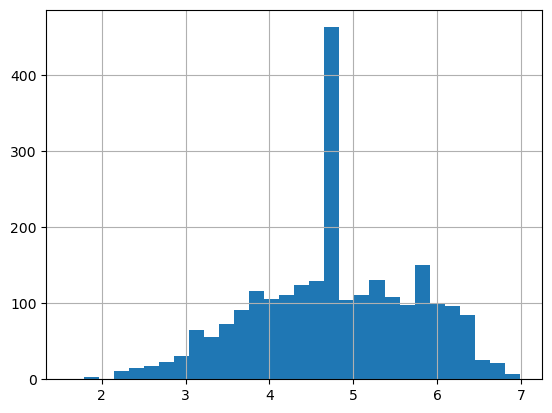

In [33]:
df_model['rooms_count_log'] = np.log1p(df_model['rooms_count'])
df_model['rooms_count_log'].hist(bins=30)

##### 3.4.3.2 Location of hotels

<Axes: xlabel='gmap_longitude', ylabel='gmap_latitude'>

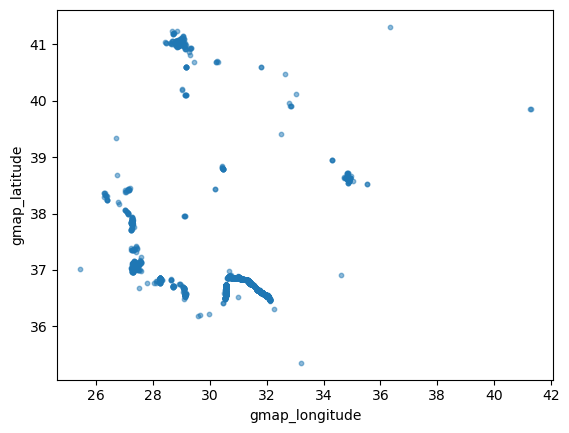

In [34]:
df_model.plot(
    x='gmap_longitude',
    y='gmap_latitude',
    kind='scatter',
    alpha=0.5,
    s=10
)

In [35]:
# DBSCAN works with distances on a sphere, so coordinates are converted to radians
coords = df_model[['gmap_latitude', 'gmap_longitude']].to_numpy()
coords_rad = np.radians(coords)

# Radius of the Earth in kilometers
earth_radius_km = 6371

eps_km = 30
eps_rad = eps_km / earth_radius_km

geo_cluster_model = DBSCAN(
    eps=eps_rad,
    min_samples=3,
    metric='haversine'
)

df_model['geo_cluster'] = geo_cluster_model.fit_predict(coords_rad)

In [36]:
df_model['geo_cluster'].value_counts().sort_index()

geo_cluster
-1       20
 0      755
 1     1011
 2      198
 3       89
 4      200
 5       13
 6      136
 7        5
 8        3
 9        8
 10      13
 11      11
 12       4
 13       4
Name: count, dtype: int64

<Axes: xlabel='gmap_longitude', ylabel='gmap_latitude'>

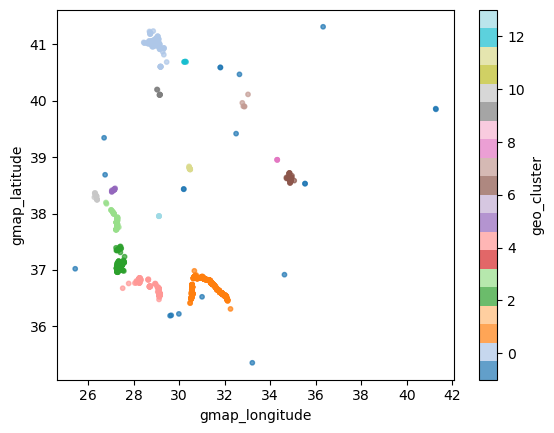

In [37]:
df_model.plot(
    x='gmap_longitude',
    y='gmap_latitude',
    kind='scatter',
    c='geo_cluster',
    colormap='tab20',
    alpha=0.7,
    s=10
)

In [39]:
n_clusters = df_model[df_model['geo_cluster'] != -1]['geo_cluster'].nunique()
n_outliers = (df_model['geo_cluster'] == -1).sum()
outliers_share = n_outliers / len(df_model) * 100

print('Number of clusters:', n_clusters)
print('Number of outliers:', n_outliers)
print('Share of outliers:', round(outliers_share, 2), '%')

Number of clusters: 14
Number of outliers: 20
Share of outliers: 0.81 %


In [40]:
df_model.dtypes

id                     int64
name                  object
gmap_latitude        float64
gmap_longitude       float64
category_name         object
                      ...   
hotel_type_count       int64
internet_has_info      int32
internet_count         int64
rooms_count_log      Float32
geo_cluster            int64
Length: 69, dtype: object

## 4. Final preprocessing output

In [41]:
service_info_cols = [col + '_has_info' for col in service_cols]

df_model['service_info_count'] = df_model[service_info_cols].sum(axis=1)
df_model['service_info_share'] = df_model[service_info_cols].mean(axis=1)

In [43]:
def list_to_text(values):
    if not isinstance(values, list):
        return ''
    
    if len(values) == 0:
        return ''
    
    return ', '.join(values)


def make_canonical_text(row):
    parts = []
    
    parts.append(f"hotel name: {row['name']}")
    parts.append(f"category: {row['category_clean']}")
    parts.append(f"stars: {row['hotel_stars_for_model']}")
    parts.append(f"geo cluster: {row['geo_cluster']}")
    parts.append(f"rooms count: {row['rooms_count']}")
    parts.append(f"pets policy: {row['pets_policy']}")
    
    # Services
    for col in service_cols:
        has_info_col = col + '_has_info'
        
        if row[has_info_col] == 1:
            text_value = list_to_text(row[col])
            
            if text_value != '':
                parts.append(f"{col}: {text_value}")
    
    return '. '.join(parts)


df_model['canonical_text'] = df_model.apply(make_canonical_text, axis=1)

In [45]:
base_cols = [
    'id',
    'name',
    'category_name',
    'category_clean',
    'hotel_stars',
    'hotel_stars_for_model',
    'pets_policy',
    'has_pets_info',
    'rooms_count_original',
    'rooms_count',
    'rooms_count_missing',
    'rooms_count_log',
    'gmap_latitude',
    'gmap_longitude',
    'geo_cluster',
    'service_info_count',
    'service_info_share',
    'canonical_text'
]

service_feature_cols = []

for col in service_cols:
    service_feature_cols.append(col)
    service_feature_cols.append(col + '_has_info')
    service_feature_cols.append(col + '_count')

final_cols = base_cols + service_feature_cols

hotels_preprocessed_df = df_model[final_cols].copy()

In [46]:
hotels_preprocessed = hotels_preprocessed_df.to_dict(orient='records')

with open('hotels_preprocessed.pkl', 'wb') as file:
    pickle.dump(hotels_preprocessed, file)